## Qubit + cavidad en el THz
Sea un qubit acoplado a dos cavidades:
1. Una de ellas con frecuencia en el óptico. Acoplo muy débil que permite hallar su espectro de emisión
2. Otra con frecuencia en el régimen THz

El objetivo es estudiar el efecto del acoplo entre el qubit y THz en el espectro de emisión.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

Parámetros físicos

In [18]:
w_L = 10     #frecuencia del laser del drive
w_b = 30     #frecuencia de resonancia en el THz 
Delta_q = 0  #detuning qubit por el láser
Omega = 20   # drive del qubit

gamma = 1       #decay en el qubit
kappa_a = 1     #decay en la cavidad del sensor
kappa_b = 1     #decay en la cav de THz

g = 0.001       # acoplo qubit optico
chi =  0.2      # acoplo qubit THz

Na = 2        # truncación de la primera cavidad 
Nb = 5          # segunda cavidad



Operadores

In [19]:
# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na), qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores
Dissipators = []

Dissipators.append(np.sqrt(gamma) * sm)
Dissipators.append(np.sqrt(kappa_a) * a)
Dissipators.append(np.sqrt(kappa_b) * b)

Barrido en valores de w_a

In [20]:
# eje horizontal (frecuencia espectral)
Delta_a_list = np.linspace(-3*Omega, 3*Omega, 150)

# Detuning del qubit
Delta_q = 0

spectrum = []


# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(-3*Omega, 3*Omega, 150)

# matriz para guardar el espectro
S_map = np.zeros((len(Delta_q_list), len(Delta_a_list)))

Hamiltoniano: $$H = \frac{\Omega}{2}\sigma_x + \omega_{THz}b^\dagger b+ \Delta_a a^\dagger a +\Delta_q\sigma_z + g(a^\dagger\sigma_- + a\sigma_+) + \chi(\sigma_z+1)(a + a^\dagger)$$

Cuando la cavidad está muy debilmente acoplada, podemos calcular el espectro como $$S(\omega)\ \alpha\ \braket{a^\dagger a}^{SS}$$.


Donde $$\braket{a^\dagger a}^{SS} = Tr(\rho_{SS}a^\dagger a)$$

1: S(w) Vs Delta_a, para un Delta_q fijo en Delta_q = 0

In [21]:
for Delta_a in Delta_a_list:
    
    # Hamiltoniano
    H = (Omega/2) * sx \
        + Delta_a * a_plus * a + Delta_q * sz \
        + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(a_plus + a)

    #  Steady state
    rho_SS = steadystate(H, Dissipators)
    
    # Poblacion en el SS = Tr(a^\dagger a * rho_SS )
    pop_SS = expect(a_plus * a,rho_SS)

    # Espectro
    spectrum.append(pop_SS)

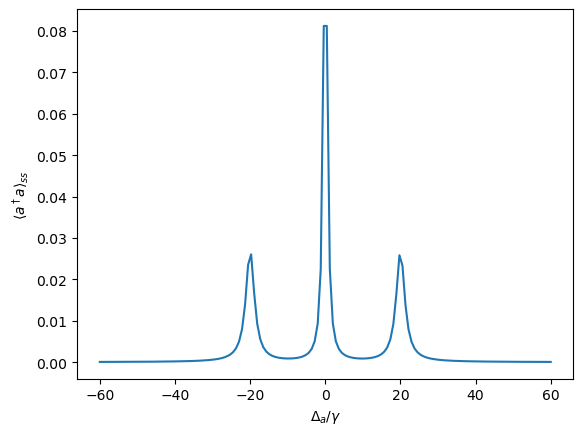

In [22]:
plt.figure()
plt.plot(Delta_a_list , spectrum)
plt.xlabel("$\\Delta_a/\\gamma$")
plt.ylabel(r"$\langle a^\dagger a \rangle_{ss}$")
plt.show()

2: Mapa S(w) con $\Delta_q$ y $\Delta_a$

In [23]:
# Doble bucle
for i, Delta_q in enumerate(Delta_q_list):
    
    # Ajustamos w_L para imponer ese Delta_q
    w_q = w_L + Delta_q
    for j, Delta_a in enumerate(Delta_a_list):
        
        w_a = +w_L + Delta_a
        
       # Hamiltoniano
        H = (Omega/2) * sx \
        + Delta_a * a_plus * a + Delta_q * sz \
        + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(a_plus + a)

        rho_SS = steadystate(H, Dissipators)
        
        S_map[i, j] = expect(a_plus*a, rho_SS)

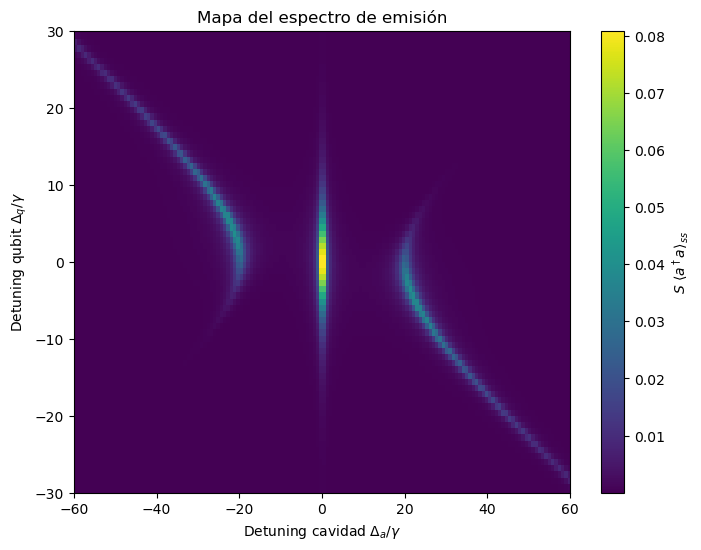

In [24]:
# ------------------------
# Gráfica tipo mapa
# ------------------------

plt.figure(figsize=(8,6))

plt.imshow(
    S_map,
    extent=[Delta_a_list[0], Delta_a_list[-1],
            Delta_q_list[0], Delta_q_list[-1]],
    aspect='auto',
    origin='lower'
)

plt.xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
plt.ylabel("Detuning qubit $\\Delta_q/\\gamma$")
plt.title("Mapa del espectro de emisión")
plt.ylim(-30,30)
plt.colorbar(label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

plt.show()